In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib
import os

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

In [44]:
#Load & Inspect
df = pd.read_csv("data/house_prices.csv")

print("Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nDataset Info:")
df.info()

print("\nMissing values ratio:")
print(df.isna().mean().sort_values(ascending=False))


Shape: (187531, 21)

First 5 rows:


,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN



Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  str    
 2   Description        184508 non-null  str    
 3   Amount(in rupees)  187531 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  str    
 6   Carpet Area        106858 non-null  str    
 7   Status             186916 non-null  str    
 8   Floor              180454 non-null  str    
 9   Transaction        187448 non-null  str    
 10  Furnishing         184634 non-null  str    
 11  facing             117298 non-null  str    
 12  overlooking        106095 non-null  str    
 13  Society            77853 non-null   str    
 14  Bathroom           186703 non-null  str    
 15  Balcony            138596 non-null  str    
 16

In [45]:
#2.3 Cleaning & Feature Engineering
# --- Step 1: price is stored as text (e.g. "42 Lac", "1.2 Cr"), so convert it to a plain number ---
def parse_amount(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    try:
        if "lac" in x:
            return float(x.replace("lac", "").strip()) * 1e5
        if "cr" in x:
            return float(x.replace("cr", "").strip()) * 1e7
        return float(x.replace(",", ""))
    except ValueError:
        return None
df["price_clean"] = df["Amount(in rupees)"].apply(parse_amount)
df = df.dropna(subset=["price_clean"]).copy()  # drop rows where we couldn't parse a price at all
# --- Step 2: area is also text, and sometimes in sqm instead of sqft, so normalize it ---
def parse_area(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    try:
        if "sqft" in x:
            return float(x.replace("sqft", "").strip())
        if "sqm" in x:
            return float(x.replace("sqm", "").strip()) * 10.764  # convert sqm -> sqft
        return float(x)
    except ValueError:
        return None

df["carpet_area_sqft"] = df["Carpet Area"].apply(parse_area)
# --- Step 3: floor comes as something like "3 out of 10", we only need the "3" ---
def parse_floor(x):
    if not isinstance(x, str):
        return 0
    x = x.strip().lower()
    if "ground" in x or "basement" in x:
        return 0
    try:
        return int(x.split("out")[0].strip())
    except Exception:
        return 0

df["floor_num"] = df["Floor"].apply(parse_floor)
# --- Step 4: bathroom/balcony should be numbers, fill missing with 0 like the guide says ---
for col in ["Bathroom", "Balcony"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)
# --- Step 5: extra categorical columns the backend will need later ---
# just making sure they exist and don't have missing values before we get to modeling
for col in ["Furnishing", "Transaction", "Ownership", "facing"]:
    if col in df.columns:
        df[col] = df[col].fillna("Unknown").astype(str).str.strip()
    else:
        df[col] = "Unknown"

print("Cleaned Dataset Shape (before outlier removal):", df.shape)
# --- Step 6: remove outliers based on price per sqft (some listings are obviously broken/fake) ---
df = df[df["carpet_area_sqft"] > 0].copy()  # avoid division by zero
df["price_per_sqft"] = df["price_clean"] / df["carpet_area_sqft"]

lower_bound = df["price_per_sqft"].quantile(0.01)
upper_bound = df["price_per_sqft"].quantile(0.99)

df = df[(df["price_per_sqft"] >= lower_bound) & (df["price_per_sqft"] <= upper_bound)].copy()
df = df.drop(columns=["price_per_sqft"])  # was just a helper column, don't need it anymore

print("Cleaned Dataset Shape (after outlier removal):", df.shape)


Cleaned Dataset Shape (before outlier removal): (177847, 24)
Cleaned Dataset Shape (after outlier removal): (95263, 24)


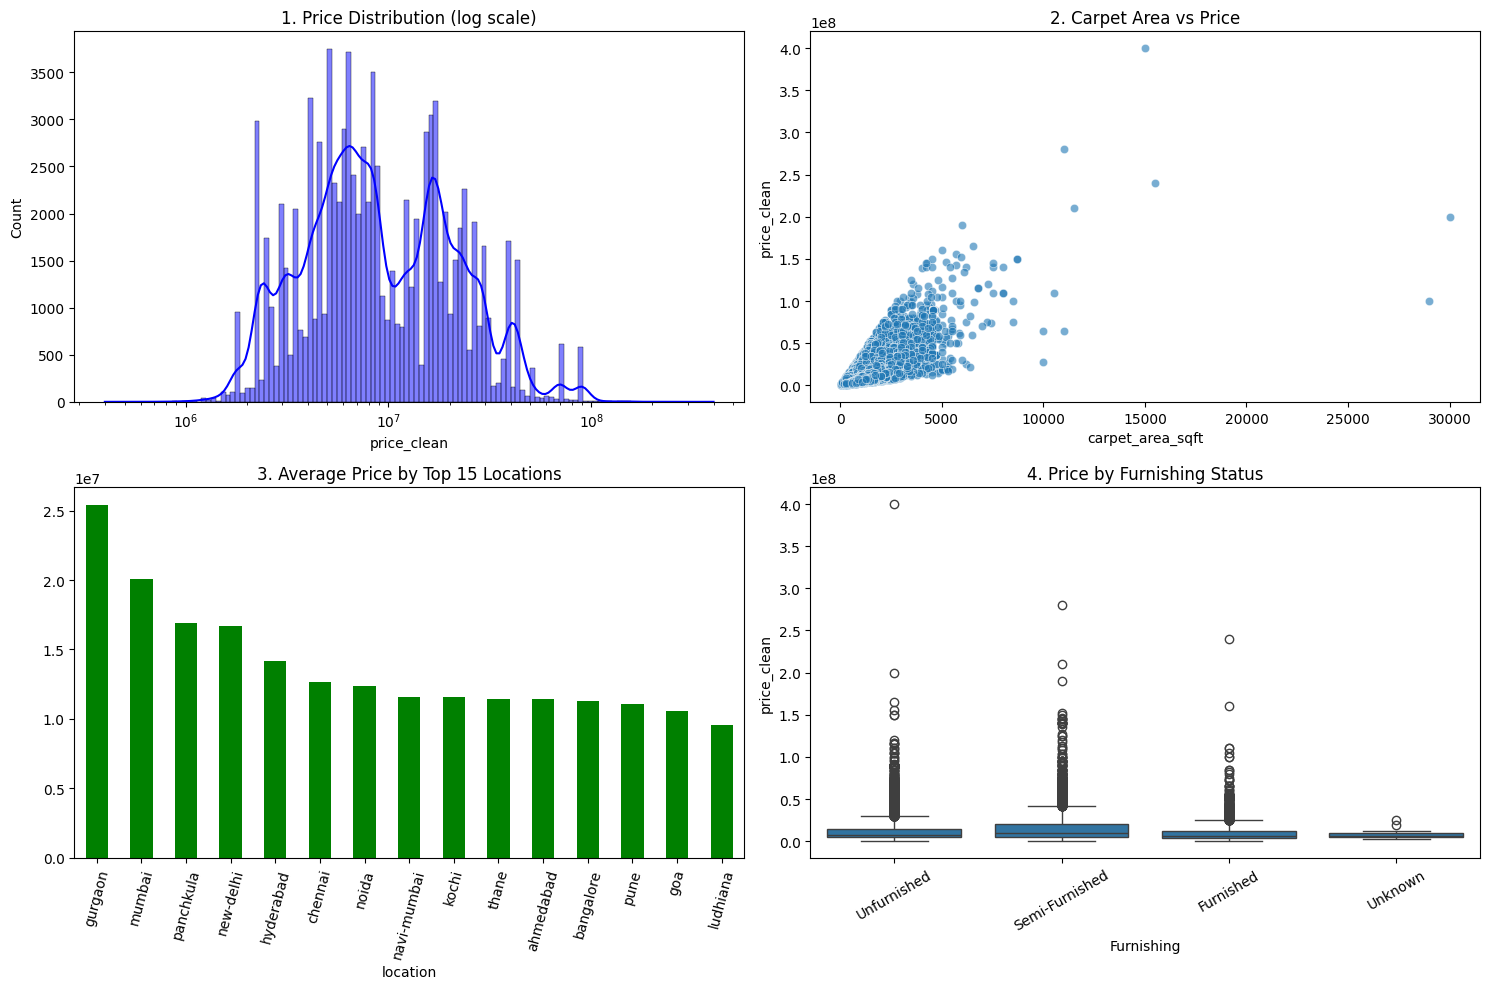

In [46]:
#Exploratory Data Analysis (EDA)
plt.figure(figsize=(15, 10))

# Chart 1: price is heavily skewed, so log scale makes it actually readable
plt.subplot(2, 2, 1)
sns.histplot(df["price_clean"], kde=True, color="blue", log_scale=True)
plt.title("1. Price Distribution (log scale)")
# Chart 2: bigger area should generally mean higher price, let's see if that holds
plt.subplot(2, 2, 2)
sns.scatterplot(data=df, x="carpet_area_sqft", y="price_clean", alpha=0.6)
plt.title("2. Carpet Area vs Price")

# Chart 3: which locations are the priciest on average (not just most listed)
plt.subplot(2, 2, 3)
df.groupby("location")["price_clean"].mean().sort_values(ascending=False).head(15).plot(kind="bar", color="green")
plt.title("3. Average Price by Top 15 Locations")
plt.xticks(rotation=75)
# Chart 4: does furnishing status actually move the price? box plot shows spread nicely
plt.subplot(2, 2, 4)
sns.boxplot(data=df, x="Furnishing", y="price_clean")
plt.title("4. Price by Furnishing Status")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [47]:
#Build a Pipeline & Train
features = ['carpet_area_sqft', 'floor_num', 'location']
target = 'price_clean'

# drop any rows still missing something we actually need for training
model_df = df.dropna(subset=features + [target]).copy()

# location has thousands of unique values, so keep the top 30 and dump the rest into "other"
top_locs = model_df['location'].value_counts().head(30).index
model_df['location_grouped'] = model_df['location'].apply(lambda x: x if x in top_locs else 'other')

num_features = ['carpet_area_sqft', 'floor_num']
cat_features = ['location_grouped']

X = model_df[num_features + cat_features]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# bundling preprocessing + model together so the exported pkl handles everything by itself
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ]
)

# --- Model 1: Linear Regression, just as a simple baseline to compare against ---
lr_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

# --- Model 2: Random Forest, should handle the non-linear stuff better ---
rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1))
])
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

# Comparison Results
print("\n--- Model Comparison ---")
print(f"Linear Regression -> R2: {r2_score(y_test, lr_pred):.4f} | MAE: {mean_absolute_error(y_test, lr_pred):,.2f}")
print(f"Random Forest     -> R2: {r2_score(y_test, rf_pred):.4f} | MAE: {mean_absolute_error(y_test, rf_pred):,.2f}")


--- Model Comparison ---
Linear Regression -> R2: 0.7178 | MAE: 4,316,083.06
Random Forest     -> R2: 0.9207 | MAE: 1,197,011.02



--- Model Comparison (on Test Set) ---


,Model,MAE,RMSE,R2
0,Linear Regression,4.316083e+06,7.068046e+06,0.717766
1,Random Forest,1.197011e+06,3.746017e+06,0.920723


Random Forest 5-fold CV R2 scores: [ 0.5299      0.72755754  0.67475734  0.91209819 -0.11306284]
Mean CV R2: 0.546250044878895


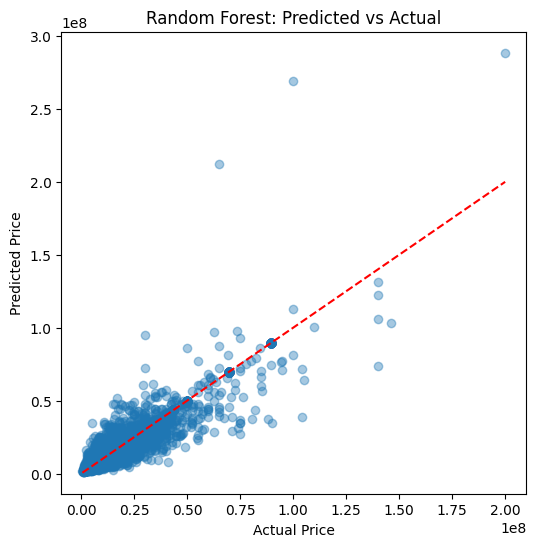

In [48]:
# 2.5 Evaluate
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = root_mean_squared_error(y_test, lr_pred)
lr_r2 = r2_score(y_test, lr_pred)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = root_mean_squared_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("\n--- Model Comparison (on Test Set) ---")
comparison_table = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [lr_mae, rf_mae],
    "RMSE": [lr_rmse, rf_rmse],
    "R2": [lr_r2, rf_r2]
})
display(comparison_table)

# bonus: 5-fold cross validation on the better model, just to double check it's not overfitting
cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring='r2', n_jobs=-1)
print("Random Forest 5-fold CV R2 scores:", cv_scores)
print("Mean CV R2:", cv_scores.mean())
# quick visual check: how close are predictions to the real values (closer to red line = better)
plt.figure(figsize=(6, 6))
plt.scatter(y_test, rf_pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Random Forest: Predicted vs Actual")
plt.show()

# Conclusion: Random Forest wins here - higher R2 and lower MAE/RMSE than Linear Regression,
# since it can capture the non-linear relationship between area/location and price better.
# So this is the model we're exporting and using in the backend.


In [49]:
#Export the Model
os.makedirs("../backend/models", exist_ok=True)

joblib.dump(rf_model, "../backend/models/house_price_model.pkl")

# quick sanity check - reload the saved model and make sure it still predicts fine
loaded = joblib.load("../backend/models/house_price_model.pkl")
sample = X_test.iloc[[0]]
print("Reloaded prediction:", loaded.predict(sample))

# save metadata (locations + features) in the format the backend expects
metadata = {
    "locations": sorted(model_df["location_grouped"].unique().tolist()),
    "features": list(X_test.columns)
}
json.dump(metadata, open("../backend/models/metadata.json", "w"))

print("\nBest Model (Random Forest) and metadata.json saved successfully in 'backend/models/' folder!")

Reloaded prediction: [3823585.71428571]

Best Model (Random Forest) and metadata.json saved successfully in 'backend/models/' folder!
